In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import linopy as lp
import pypsa
print(pypsa.__version__)
import gurobipy as gp

print("Gurobi version:", gp.gurobi.version())

1.1.2
Gurobi version: (13, 0, 1)


In [2]:
%pip install linopy
%pip install gurobipy
%pip install pypsa matplotlib cartopy highspy
%pip install Gurobi
%pip install numpy
%pip install pandas


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement Gurobi (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for Gurobi
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart 

In [3]:
import xarray as xr
print(xr.__version__)

2026.2.0


In [4]:
# =====================
# LOAD DATA
# =====================

# load electricity demand data
df_elec = pd.read_csv('electricity_demand.csv', sep=';', index_col=0) # in MWh
df_elec.index = pd.to_datetime(df_elec.index) #change index to datatime
country='DEU'
print(df_elec[country].head())

# load onshore wind data
df_onshorewind = pd.read_csv('onshore_wind_1979-2017.csv', sep=';', index_col=0)
df_onshorewind.index = pd.to_datetime(df_onshorewind.index)

# load offshore wind data
df_offshorewind = pd.read_csv('offshore_wind_1979-2017.csv', sep=';', index_col=0)
df_offshorewind.index = pd.to_datetime(df_offshorewind.index)

# load large scale pv data
df_pv = pd.read_csv('pv_optimal.csv', sep=';', index_col=0)
df_pv.index = pd.to_datetime(df_pv.index)

# load rooftop pv data
df_rooftop = pd.read_csv('pv_rooftop.csv', sep=';', index_col=0)
df_rooftop.index = pd.to_datetime(df_rooftop.index)

utc_time
2015-01-01 00:00:00+00:00    44546.0
2015-01-01 01:00:00+00:00    42967.0
2015-01-01 02:00:00+00:00    41582.0
2015-01-01 03:00:00+00:00    40964.0
2015-01-01 04:00:00+00:00    40247.0
Name: DEU, dtype: float64


In [5]:
colors = {"onshore": "blue", "offshore": "darkblue", "pv": "orange", 
          "rooftop": "yellow", "coal": "brown", "OCGT": "grey"}

In [6]:
 # =====================
# MAKE NETWORK
# =====================
 
def annuity(n,r):
    """ Calculate the annuity factor for an asset with lifetime n years and
    discount rate  r """

    if r > 0:
        return r/(1. - 1./(1.+r)**n)
    else:
        return 1/n

In [7]:
network = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

network.set_snapshots(hours_in_2015.values)

# add electricity bus
network.add("Bus",
            f"E_bus{country}")

# add load to the bus
network.add("Load",
            "load",
            bus=f"E_bus{country}",
            p_set=df_elec[country].values)

# add the different carriers, only gas emits CO2
network.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
network.add("Carrier", "coal", co2_emissions=0.9) # in t_CO2/MWh_th
network.add("Carrier", "onshorewind")
network.add("Carrier", "offshorewind")
network.add("Carrier", "solarPV")
network.add("Carrier", "rooftopPV")

''' Add renewable generators '''
# Add onshore wind
CF_wind_onshore = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 30 # years
discount_rate = 0.07 # 7%
capex = 910000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_onshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "onshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_onshore.values)

# Add offshore wind
CF_wind_offshore = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 2506000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_offshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "offshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="offshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_offshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_offshore.values)

# Add large scale solar
CF_solar = df_pv[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 425000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_pv = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "PV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="solarPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_pv,
            marginal_cost = 0,
            p_max_pu = CF_solar.values)

# Add rooftop solar
CF_rooftop = df_rooftop[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 725000 # in €/MW
fopex = 0.02 # 2% of capex
capital_cost_rooftop = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "rooftopPV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="rooftopPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_rooftop,
            marginal_cost = 0,
            p_max_pu = CF_rooftop.values)

''' Add non-renewables generators '''
# add OCGT (Open Cycle Gas Turbine) generator
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 560000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_OCGT = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "OCGT",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            efficiency = efficiency,
            marginal_cost = marginal_cost_OCGT)

# add coal generator (without CCS) # https://atb-archive.nrel.gov/electricity/2018/index.html?t=cc
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 3294000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_coal = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 4 # in €/MWh_th 
efficiency = 0.36 # MWh_elec/MWh_th
marginal_cost_coal = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "coal",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="coal",
            #p_nom_max=1000,
            capital_cost = capital_cost_coal,
            efficiency = efficiency,
            marginal_cost = marginal_cost_coal)



In [8]:
network.optimize(solver_name='gurobi')

/var/folders/6w/b824ws7s0yvdbd5wwn1806680000gn/T/ipykernel_24923/3854944838.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['E_busDEU'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 152.38it/s]
INFO:linopy.io: Writing time: 0.19s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2788995


INFO:gurobipy:Set parameter LicenseID to value 2788995


...

Solved in 13312 iterations and 4.11 seconds (1.07 work units)


INFO:gurobipy:Solved in 13312 iterations and 4.11 seconds (1.07 work units)


Optimal objective  2.475321425e+10


INFO:gurobipy:Optimal objective  2.475321425e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 2.48e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [10]:
Print Out the Results

SyntaxError: invalid syntax (3330630411.py, line 1)

In [11]:
print(f"Total cost: {round(network.objective/1000000,2)} mio€")
print(f"Cost per MWh of electricity produced {round(float(network.objective/network.loads_t.p.sum().iloc[0]))} EUR/MWh")


Total cost: 24753.21 mio€
Cost per MWh of electricity produced 49 EUR/MWh


(np.float64(-1.0999999610572813),
 np.float64(1.0999999981455848),
 np.float64(-1.0999999845940491),
 np.float64(1.1000000044956866))

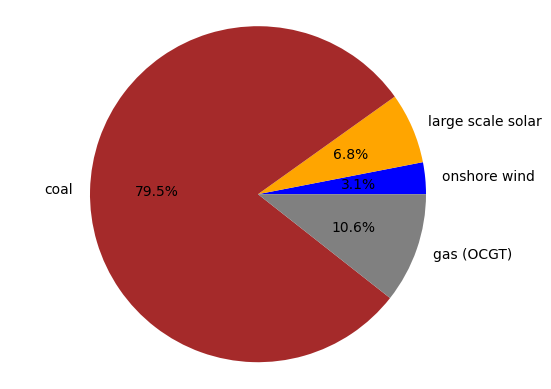

In [13]:
labels = ['onshore wind',
            #'offshore wind',
            'large scale solar',
            #'rooftop solar',
            'coal',
            'gas (OCGT)']
       
sizes = [network.generators_t.p['onshorewind'].sum(),
            #network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['PV'].sum(),
            #network.generators_t.p['rooftopPV'].sum(),
            network.generators_t.p['coal'].sum(),
         network.generators_t.p['OCGT'].sum()]

colors=['blue', 'orange', 'brown', 'grey']

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0},
        autopct='%1.1f%%')
plt.axis('equal')

In [14]:
network.generators.p_nom_opt.div(1e3) # in GW

name
onshorewind      8.350420
offshorewind     0.000000
PV              33.368777
rooftopPV        0.000000
OCGT            28.614407
coal            48.134363
Name: p_nom_opt, dtype: float64

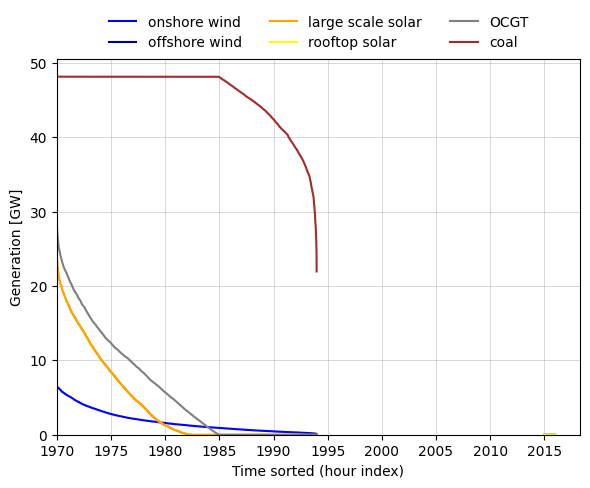

In [15]:
colors = ['blue', 'darkblue', 'orange', 'yellow', 'brown', 'grey']

# Duration Curves (in GW)
cf_onshore = network.generators_t.p['onshorewind'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_offshore = network.generators_t.p['offshorewind'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_PV = network.generators_t.p['PV'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_rooftopPV = network.generators_t.p['rooftopPV'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_OCGT = network.generators_t.p['OCGT'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_coal = network.generators_t.p['coal'].sort_values(ascending=False, ignore_index=True) / 1e3

plt.figure(figsize=(6, 5))

plt.plot(cf_onshore, color='blue')
plt.plot(cf_offshore, color='darkblue')
plt.plot(cf_PV, color='orange')
plt.plot(cf_rooftopPV, color='yellow')
plt.plot(cf_OCGT, color='grey')
plt.plot(cf_coal, color='brown')

plt.grid(True, which='both', linewidth=0.5, alpha=0.7)
plt.ylabel('Generation [GW]')
plt.xlabel('Time sorted (hour index)')

# Force axes to start at 0
plt.ylim(bottom=0)
plt.xlim(left=0)

# Legend on top center
plt.legend(['onshore wind', 'offshore wind', 'large scale solar', 'rooftop solar', 'OCGT', 'coal'],
           loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)

plt.tight_layout()
plt.show()


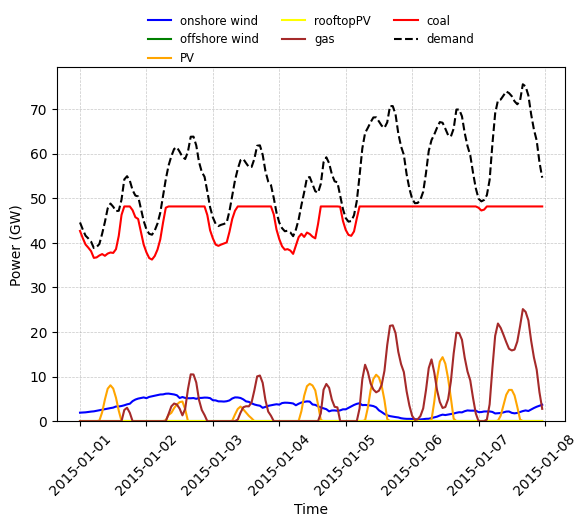

In [16]:
start_date_1 = '2015-01-01'
end_date_1 = '2015-01-07'
week_1 = network.generators_t.p.loc[start_date_1:end_date_1] / 1e3  # Convert to GW
demand = network.loads_t.p['load'].loc[start_date_1:end_date_1] / 1e3  # Convert to GW

plt.figure(figsize=(6, 5.5))

plt.plot(week_1['onshorewind'], color='blue', label='onshore wind')
plt.plot(week_1['offshorewind'], color='green', label='offshore wind')
plt.plot(week_1['PV'], color='orange', label='PV')
plt.plot(week_1['rooftopPV'], color='yellow', label='rooftopPV')
plt.plot(week_1['OCGT'], color='brown', label='gas')
plt.plot(week_1['coal'], color='red', label='coal')
plt.plot(demand, color='black', label='demand', linestyle='--')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(bottom=0)
plt.xlabel('Time')
plt.ylabel('Power (GW)')  # Updated unit
plt.xticks(rotation=45)

plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.18),
           ncol=3,
           fontsize='small',
           frameon=False)

plt.tight_layout()
plt.show()

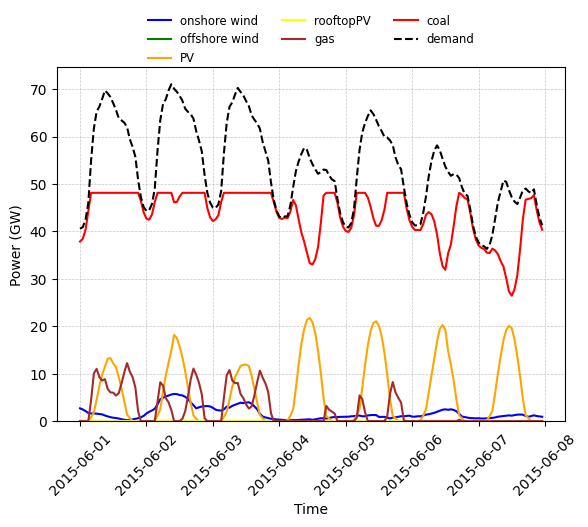

In [17]:
# Summer week time slice
start_date_2 = '2015-06-01'
end_date_2 = '2015-06-07'
week_2 = network.generators_t.p.loc[start_date_2:end_date_2] / 1e3  # Convert to GW
demand_2 = network.loads_t.p['load'].loc[start_date_2:end_date_2] / 1e3  # Convert to GW

plt.figure(figsize=(6, 5.5))

plt.plot(week_2['onshorewind'], color='blue', label='onshore wind')
plt.plot(week_2['offshorewind'], color='green', label='offshore wind')
plt.plot(week_2['PV'], color='orange', label='PV')
plt.plot(week_2['rooftopPV'], color='yellow', label='rooftopPV')
plt.plot(week_2['OCGT'], color='brown', label='gas')
plt.plot(week_2['coal'], color='red', label='coal')
plt.plot(demand_2, color='black', label='demand', linestyle='--')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(bottom=0)
plt.xlabel('Time')
plt.ylabel('Power (GW)')
plt.xticks(rotation=45)

plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.18),
           ncol=3,
           fontsize='small',
           frameon=False)

plt.tight_layout()
plt.show()


In [18]:
(network.statistics.capex() + network.statistics.opex()).div(1e6)

component  carrier    
Generator  coal           18478.567500
           gas             4388.622204
           onshorewind             NaN
           solarPV                 NaN
dtype: float64

In [ ]:
Task B

In [24]:
years = df_offshorewind.index.year.unique()
years = years[(years >= 2001) & (years != 2016) & (years != 2012) & (years != 2008) & (years != 2004)]


systemcost = []
onwind = []
#offwind = []
pv = []
#rooftop = []
coal = []
ocgt = []

onwind_cap = []
#offwind_cap = []
pv_cap = []
#rooftop_cap = []
coal_cap = []
ocgt_cap = []


for year in years:
    network.generators_t.p_max_pu["onshorewind"] = df_onshorewind[country][df_onshorewind.index.year == year].values
    network.generators_t.p_max_pu["offshorewind"] = df_offshorewind[country][df_offshorewind.index.year == year].values
    network.generators_t.p_max_pu["PV"] = df_pv[country][df_pv.index.year == year].to_numpy().ravel()
    network.generators_t.p_max_pu["rooftopPV"] = df_rooftop[country][df_rooftop.index.year == year].to_numpy().ravel()
    
    network.optimize(solver_name="gurobi")
    systemcost.append(network.objective / 1e6)  # in million euros
    onwind.append(network.generators_t.p["onshorewind"].sum())
    #offwind.append(network.generators_t.p["offshorewind"].sum())
    pv.append(network.generators_t.p["PV"].sum())
    #rooftop.append(network.generators_t.p["rooftopPV"].sum())
    coal.append(network.generators_t.p["coal"].sum())
    ocgt.append(network.generators_t.p["OCGT"].sum())

    onwind_cap.append(network.generators.p_nom_opt.loc["onshorewind"])
    #offwind_cap.append(network.generators.p_nom_opt.loc["offshorewind"])
    pv_cap.append(network.generators.p_nom_opt.loc["PV"])
    #rooftop_cap.append(network.generators.p_nom_opt.loc["rooftopPV"])
    coal_cap.append(network.generators.p_nom_opt.loc["coal"])
    ocgt_cap.append(network.generators.p_nom_opt.loc["OCGT"])
    

/var/folders/6w/b824ws7s0yvdbd5wwn1806680000gn/T/ipykernel_24923/3353813259.py:27: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="gurobi")
Index(['E_busDEU'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 162.72it/s]
INFO:linopy.io: Writing time: 0.1s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2788995


INFO:gurobipy:Set parameter LicenseID to value 2788995


...

Solved in 33067 iterations and 2.99 seconds (1.03 work units)


INFO:gurobipy:Solved in 33067 iterations and 2.99 seconds (1.03 work units)


Optimal objective  2.492583166e+10


INFO:gurobipy:Optimal objective  2.492583166e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 2.49e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


ValueError: setting an array element with a sequence.

In [25]:
years_array = np.array([2001, 2002, 2003, 2005, 2006, 2007, 2009, 2010, 2011, 2013, 2014, 2015, 2017])  # match your data
results = pd.DataFrame(
    np.array([np.array(onwind_cap)/10**3, np.array(pv_cap)/10**3,
             np.array(coal_cap)/10**3, np.array(ocgt_cap)/10**3]).T,
    columns=["onshorewind", "PV", "coal", "OCGT"],
    index=years_array,
)
 
# Make a boxplot
plt.figure(figsize=(14, 6))
plt.boxplot(
    [results["onshorewind"], results["PV"], results["coal"], results["OCGT"]],
    labels=["onshore wind", "PV", "coal", "OCGT"]
)
plt.ylabel("Generation Capacity (GW)")
plt.ylim(bottom=0)
plt.grid(True, linewidth=0.5, alpha=0.7)
plt.xlabel("Generation Type")
 

ValueError: Empty data passed with indices specified.

In [ ]:
Section C

In [ ]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

# add electricity bus
n.add("Bus",
            f"E_bus{country}")

# add load to the bus
n.add("Load",
            "load",
            bus=f"E_bus{country}",
            p_set=df_elec[country].values)

# add the different carriers, only gas emits CO2
n.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
n.add("Carrier", "coal", co2_emissions=0.9) # in t_CO2/MWh_th
n.add("Carrier", "onshorewind")
n.add("Carrier", "offshorewind")
n.add("Carrier", "solarPV")
n.add("Carrier", "rooftopPV")

''' Add renewable generators '''
# Add onshore wind
CF_wind_onshore = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 30 # years
discount_rate = 0.07 # 7%
capex = 910000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_onshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "onshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_onshore.values)
'''
# Add offshore wind
CF_wind_offshore = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 2506000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_offshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "offshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="offshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_offshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_offshore.values)
'''
# Add large scale solar
CF_solar = df_pv[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 425000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_pv = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "PV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="solarPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_pv,
            marginal_cost = 0,
            p_max_pu = CF_solar.values)
'''
# Add rooftop solar
CF_rooftop = df_rooftop[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 725000 # in €/MW
fopex = 0.02 # 2% of capex
capital_cost_rooftop = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "rooftopPV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="rooftopPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_rooftop,
            marginal_cost = 0,
            p_max_pu = CF_rooftop.values)
'''

''' Add non-renewables generators '''
# add OCGT (Open Cycle Gas Turbine) generator
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 560000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_OCGT = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
n.add("Generator",
            "OCGT",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            efficiency = efficiency,
            marginal_cost = marginal_cost_OCGT)

# add coal generator (without CCS) # https://atb-archive.nrel.gov/electricity/2018/index.html?t=cc
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 3294000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_coal = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 4 # in €/MWh_th 
efficiency = 0.36 # MWh_elec/MWh_th
marginal_cost_coal = fuel_cost/efficiency # in €/MWh_el
n.add("Generator",
            "coal",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="coal",
            #p_nom_max=1000,
            capital_cost = capital_cost_coal,
            efficiency = efficiency,
            marginal_cost = marginal_cost_coal)


# Add storage unit
n.add("StorageUnit",
            "battery",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            capital_cost=12894+24678,
            efficiency_dispatch=0.96,
            efficiency_store=0.96,
            max_hours=2,
            cyclic_state_of_charge=True,)

# Co2 Cap
n.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=152000000, #152MtCO2
)

In [ ]:
n.optimize(solver_name='gurobi')

In [ ]:
n.generators_t.p.loc["2015-01"].plot.area(figsize=(12, 4), ylabel="dispatch", color=['blue', 'orange', 'brown', 'grey'])


In [ ]:
labels = ['onshore wind',
            #'offshore wind',
            'large scale solar',
            'coal',
            'gas (OCGT)']
      
sizes = [n.generators_t.p['onshorewind'].sum(),
         #n.generators_t.p['offshorewind'].sum(),
         n.generators_t.p['PV'].sum(),
         n.generators_t.p['coal'].sum(),
         n.generators_t.p['OCGT'].sum()]
 
colors=['blue', 'orange', 'brown', 'grey']
 
plt.figure(figsize=(6, 4))
plt.pie(
    sizes,
    colors=colors,
    labels=labels,
    autopct='%1.1f%%',  # Show percentages with 1 decimal place
    pctdistance=0.8,
    textprops={'fontsize': 12},
    startangle=0,      # Optional: rotate start for aesthetic
    wedgeprops={'linewidth': 0}
)
plt.axis('equal')  # Keeps pie chart circular
plt.legend(fancybox=True, shadow=True, loc='right')
#plt.title('Generation Mix', y=1.07, fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
# Storage installed capacity
print(f"Installed capacity of storage: {n.storage_units.p_nom_opt.loc['battery'] / 1e3} GW")

In [ ]:
n.storage_units_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

In [ ]:
battery_power = n.storage_units_t.p.loc["2015"]

# Charging (negative) and Discharging (positive)
charging_power = battery_power.where(battery_power < 0, 0)
discharging_power = battery_power.where(battery_power > 0, 0)

# Monthly sums in GWh
monthly_charging = charging_power.resample("ME").sum() / 1e3
monthly_discharging = discharging_power.resample("ME").sum() / 1e3
demand = n.loads_t.p.loc["2015", "load"].resample("ME").sum() / 1e3

# Plot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Primary axis: charging/discharging
line1, = ax1.plot(monthly_charging.index, monthly_charging, label="Charging", color="blue", marker='o')
line2, = ax1.plot(monthly_discharging.index, monthly_discharging, label="Discharging", color="orange", marker='o')
ax1.set_ylabel("Charged (-) and Discharged (+) Energy (GWh)")
ax1.set_xlabel("Month")
ax1.grid(True, alpha=0.3)

# Secondary axis: demand
ax2 = ax1.twinx()
line3, = ax2.plot(demand.index, demand, label="Demand", color="green", marker='o')
ax2.set_ylabel("Demand (GWh)")

# Combine legends from both axes and place them on top
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
day = "2015-09-05"

# Get all generator names
generators = n.generators.index

# Filter out rooftopPV and offshorewind
filtered_generators = generators[~generators.str.contains("rooftopPV|offshorewind")]

# Convert generator dispatch to GW
gen_dispatch_gw = n.generators_t.p.loc[day, filtered_generators] / 1e3

# Plot filtered generators
ax = gen_dispatch_gw.plot.area(
    figsize=(6, 4),
    ylabel="Dispatch [GW]",
    legend=False,  # We'll use a custom combined legend
    color=['blue', 'orange', 'brown', 'grey']
)

# Overlay demand and storage (in GW)
line_demand = (n.loads_t.p['load'].loc[day] / 1e3).plot(
    ax=ax, linewidth=2, linestyle="--", color="yellow", label="Demand"
)
line_battery = (n.storage_units_t.p.loc[day] / 1e3).plot(
    ax=ax, drawstyle="steps-post", linewidth=2.5, linestyle="--", color="black", label="Battery"
)

# Combine and move legend to top center
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)

plt.ylim(-20, 80)
plt.tight_layout()
plt.show()

In [ ]:
# Duration Curves
cf_onshore = n.generators_t.p['onshorewind'].sort_values(ascending=False,ignore_index=True)/1e3
#cf_offshore = n.generators_t.p['offshorewind'].sort_values(ascending=False,ignore_index=True)/1e3
cf_PV = n.generators_t.p['PV'].sort_values(ascending=False,ignore_index=True)/1e3
#cf_rooftopPV = n.generators_t.p['rooftopPV'].sort_values(ascending=False,ignore_index=True)/1e3
cf_OCGT = n.generators_t.p['OCGT'].sort_values(ascending=False,ignore_index=True)/1e3
cf_coal = n.generators_t.p['coal'].sort_values(ascending=False,ignore_index=True)/1e3


cf_onshore.plot(kind='line', ylabel='CF onshore', color='blue')
#cf_offshore.plot(kind='line', ylabel='CF offshore', color='darkblue')
cf_PV.plot(kind='line', ylabel='CF PV', color='orange')
#cf_rooftopPV.plot(kind='line', ylabel='CF rooftopPV', color='yellow')
cf_OCGT.plot(kind='line', ylabel='CF OCGT', color='grey')
cf_coal.plot(kind='line', ylabel='CF coal', color='brown')
plt.title('Duration Curves of the different generators')
plt.legend(['onshore wind', 'large scale solar', 'OCGT', 'coal'])
plt.ylabel('Generation [GW]')
plt.show()

In [ ]:
n.generators.p_nom_opt.div(1e3) # in GW

In [ ]:
print(f"Total cost: {round(n.objective/1000000,2)} mio€")
print(f"Cost per MWh of electricity produced {round(float(n.objective/n.loads_t.p.sum().iloc[0]))} EUR/MWh")


In [ ]:
day = "2015-01-05"
ax = n.generators_t.p.loc[day].plot.area(figsize=(12, 4), ylabel="Dispatch [MW]", legend=True)

# 2. Overlay storage unit dispatch as step lines
n.storage_units_t.p.loc[day].plot(ax=ax, drawstyle="steps-post", linewidth=2, linestyle="--", legend=True)

# 3. Customize
plt.title(f"Dispatch on {day}")
plt.tight_layout()
plt.ylim(-10000, 80000)
plt.show()